# DA2-MODEL-01 — Chuẩn bị dữ liệu train/test cho tín hiệu Buy/Sell

**Input:** `sv3/DA2-DATA-06/processed_data/bitcoin.parquet`  
**Output:** `X_train, X_test, y_train, y_test, scaler` (dùng lại ở MODEL-02, 03, 04)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle, os

# Load feature table từ SV3
df = pd.read_parquet('/home/jovyan/work/sv3/DA2-DATA-06/processed_data/bitcoin.parquet')
df = df.sort_values('timestamp').reset_index(drop=True)

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape: (990, 14)
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'MA10', 'MA60', 'ROC', 'MOM', 'RSI', 'stoch_k', 'stoch_d', 'label']


,timestamp,open,high,low,close,volume,MA10,MA60,ROC,MOM,RSI,stoch_k,stoch_d,label
0,2026-06-10 23:46:00,62112.55,62145.95,62025.94,62042.40,5.381025,62205.304,62211.548182,-0.371889,-231.59,19.138616,5.201289,3.552532,0
1,2026-06-10 23:47:00,62041.65,62058.01,61927.40,61927.40,4.413417,62167.958,62187.869167,-0.599446,-373.46,14.648824,0.000000,3.552532,0
2,2026-06-10 23:48:00,61931.79,62005.53,61893.99,61948.83,3.168874,62133.562,62169.481538,-0.552167,-343.96,18.223751,12.229879,5.810389,0
3,2026-06-10 23:49:00,61946.82,61953.00,61904.00,61928.01,1.355222,62101.964,62152.233571,-0.507647,-315.98,17.511175,7.586807,6.605562,0
4,2026-06-10 23:50:00,61927.78,61953.18,61875.02,61909.07,1.216499,62064.108,62136.022667,-0.607761,-378.56,16.909684,7.285292,9.033993,0


In [2]:
print('Missing values:')
print(df.isnull().sum())
print('\nPhân bố label:')
print(df['label'].value_counts())
print(f'  Buy (1): {(df["label"]==1).sum()} ({(df["label"]==1).mean()*100:.1f}%)')
print(f'  Sell(0): {(df["label"]==0).sum()} ({(df["label"]==0).mean()*100:.1f}%)')

Missing values:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
MA10         0
MA60         0
ROC          0
MOM          0
RSI          0
stoch_k      0
stoch_d      0
label        0
dtype: int64

Phân bố label:
label
1    521
0    469
Name: count, dtype: int64
  Buy (1): 521 (52.6%)
  Sell(0): 469 (47.4%)


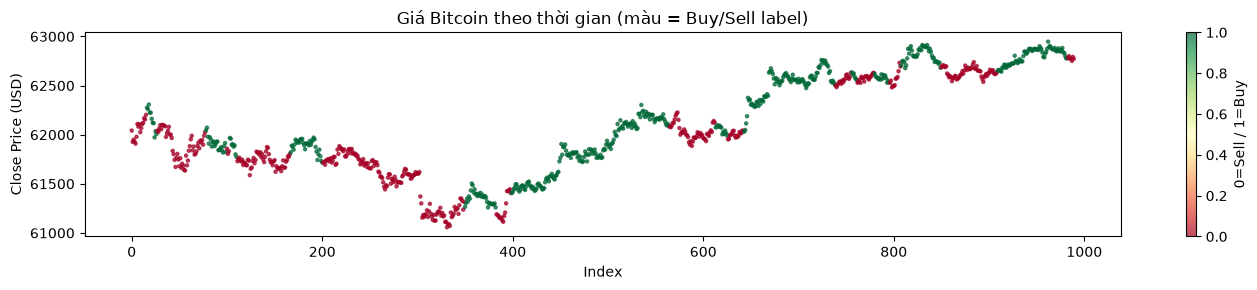

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 3))
plt.scatter(df.index, df['close'], c=df['label'], cmap='RdYlGn', s=5, alpha=0.7)
plt.colorbar(label='0=Sell / 1=Buy')
plt.title('Giá Bitcoin theo thời gian (màu = Buy/Sell label)')
plt.xlabel('Index')
plt.ylabel('Close Price (USD)')
plt.tight_layout()
plt.show()

In [4]:
# Không shuffle — chia theo thứ tự thời gian
FEATURES = ['MA10', 'MA60', 'ROC', 'MOM', 'RSI', 'stoch_k', 'stoch_d']
TARGET   = 'label'

X = df[FEATURES]
y = df[TARGET]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Tổng mẫu : {len(df)}')
print(f'Train     : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test      : {len(X_test)}  ({len(X_test)/len(df)*100:.0f}%)')
print(f'Features  : {FEATURES}')

Tổng mẫu : 990
Train     : 792 (80%)
Test      : 198  (20%)
Features  : ['MA10', 'MA60', 'ROC', 'MOM', 'RSI', 'stoch_k', 'stoch_d']


In [5]:
# Chuẩn hóa — fit trên train, transform cả hai
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler fit xong.')
print('Mean:', scaler.mean_.round(4))
print('Std :', scaler.scale_.round(4))

# Lưu để dùng ở các notebook sau
os.makedirs('/home/jovyan/work/sv4/shared', exist_ok=True)
with open('/home/jovyan/work/sv4/shared/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
np.save('/home/jovyan/work/sv4/shared/X_train_sc.npy', X_train_sc)
np.save('/home/jovyan/work/sv4/shared/X_test_sc.npy',  X_test_sc)
np.save('/home/jovyan/work/sv4/shared/y_train.npy',    y_train.values)
np.save('/home/jovyan/work/sv4/shared/y_test.npy',     y_test.values)

print('Đã lưu vào sv4/shared/ để dùng ở MODEL-02, 03, 04, EDA-01')

StandardScaler fit xong.
Mean: [6.19026773e+04 6.18892847e+04 7.40000000e-03 4.48570000e+00
 5.04328000e+01 5.02269000e+01 5.01724000e+01]
Std : [3.947027e+02 3.640952e+02 2.063000e-01 1.276272e+02 1.503610e+01
 3.040860e+01 2.782630e+01]
Đã lưu vào sv4/shared/ để dùng ở MODEL-02, 03, 04, EDA-01
